# Simulator

I just removed all stick related parameters but the overal signal function should still be the same.

Try to get reasonable output for the experimental data..., but seems way off.

In [54]:
import numpy as np

class ball_and_sticks_SSFP:
    """
    Ball&Sticks dMRI model to simulate the signal attenuation S/S0 in SSFP data.
    It assumes noise-free signal generation (i.e., no SNR is passed as a parameter).

    ## Fix the order in params as it is more convenient for you - Right now it assumes params = [bs_params, FixP, CFP]

    ---------------------------------------------
    Assumed Units for Parameters:
    ---------------------------------------------
    T1              : (ms)
    T2              : (ms)
    TR              : (ms)
    flipAngles      : degrees (converted to radians inside the model)
    B1              : unitless (relative transmit scaling factor)
    diffGradAmps    : (mT/m)
    diffGradDur     : (ms)
    gyro            : 267.513 rad/ms/mT (fixed inside the model)
    q-value         : (mm⁻¹), computed as gyro * G * τ
    ---------------------------------------------
    """
    def __init__(self, TRs, diffGradAmps, diffGradDur, flipAngles):
        self.TRs = TRs
        self.diffGradAmps = diffGradAmps
        self.diffGradDur = diffGradDur
        self.flipAngles = flipAngles
        self.gyro = 267.513 # rad/ms/mT  - 267.513e3  for rad/s/T

    def SSFP_Signal(self, bs_params, adc, E1, E2, sa, ca): # ball & sticks model in SSFP
        #bs_params = bs_params.view(-1).float()
        #self.load_CFP()
        #self.load_FixP()

        single_shell = True
        if single_shell:

            S0 = 1#bs_params[10]
            qval = self.gyro * self.diffGradAmps * self.diffGradDur / 1000.0 # units: mm⁻¹

            A1 = np.exp(-qval**2 * self.TRs * adc)
            A2 = np.exp(-qval**2 * self.diffGradDur * adc)
            A2_03 = np.exp(-qval**2 * self.diffGradDur * adc / 3.0)

            s = E2 * A1 / A2_03**4 * (1.0 - E1 * ca) + E2 / A2_03 * (ca - E1)
            r = 1.0 - E1 * ca + E2**2 * A1 * A2_03 * (ca - E1)
            K = (
                (1.0 - E1 * A1 * ca - E2**2 * A1**2 / A2_03**2 * (E1 * A1 - ca)) /
                (E2 * A1 / A2_03**4 * (1.0 + ca) * (1.0 - E1 * A1))
            )

            F1 = K - np.sqrt(K**2 - A2**2)
            Mminus_top = -(1.0 - E1) * E2 / A2_03**2 * (F1 - E2 * A1 * A2_03**2) * sa
            Mminus_bottom = r - F1 * s
            #signal = np.sqrt(np.abs(S0 * Mminus_top / Mminus_bottom)**2 + self.noisefloor**2)
            signal = Mminus_top / Mminus_bottom # Noise will be added externally
        else:
            pass

        return signal


    def __call__(self, adc_iso, T1,T2, B1): #forward model
        #bs_params = bs_params.view(-1).float()
        #self.load_CFP()
        #self.load_FixP()

        # Relaxation terms
        # T1/T2 must be in ms, no?
        E1 = np.exp(-self.TRs / (1e-3 * T1))  # T1
        E2 = np.exp(-self.TRs / (1e-3 * T2))  # T2

        # Flipping terms
        sa = np.sin(self.flipAngles * B1 * np.pi / 180.0)  # sin(flip * B1)
        ca = np.cos(self.flipAngles * B1 * np.pi / 180.0)  # cos(flip * B1)

        # Removing sticks -> just the ball
        # def project_fiber(theta, phi): #cart2sph
        #     return (
        #         self.bvecs[0] * np.sin(theta) * np.cos(phi) +
        #         self.bvecs[1] * np.sin(theta) * np.sin(phi) +
        #         self.bvecs[2] * np.cos(theta)
        #     )

        # ### for-loop fibras
        # xv_1 = project_fiber(bs_params[2], bs_params[3])
        # xv_2 = project_fiber(bs_params[5], bs_params[6])
        # xv_3 = project_fiber(bs_params[8], bs_params[9])  # third fiber

        # adc_aniso1 = bs_params[0] * xv_1**2
        # adc_aniso2 = bs_params[0] * xv_2**2
        # adc_aniso3 = bs_params[0] * xv_3**2

        # anisoterm_1 = self.SSFP_Signal(bs_params, adc_aniso1, E1, E2, sa, ca)
        # anisoterm_2 = self.SSFP_Signal(bs_params, adc_aniso2, E1, E2, sa, ca)
        # anisoterm_3 = self.SSFP_Signal(bs_params, adc_aniso3, E1, E2, sa, ca)

        #####

        isoterm = self.SSFP_Signal(None, adc_iso, E1, E2, sa, ca)
        # pred_signal = (
        #     (1 - bs_params[1] - bs_params[4] - bs_params[7]) * isoterm +
        #     bs_params[1] * anisoterm_1 +
        #     bs_params[4] * anisoterm_2 +
        #     bs_params[7] * anisoterm_3
        # )

        return isoterm


# Data

Just loading some of the data in to get inputs.

In [5]:
import nibabel as nib
import numpy as np
img = nib.load('Full_brain/Full_brain/data.nii.gz')
data = img.dataobj[150,150] # Use dataobj instead of get_fdata() to avoid loading full array
signal = np.array(data) # Convert to numpy array


bvals = np.array([
    0, 3200, 3200, 3200, 3200, 3200, 5700, 5700, 5700, 5700, 5700,
    3200, 3200, 3200, 3200, 3200, 5700, 5700, 5700, 5700, 3200, 3200,
    3200, 3200, 3200, 5700, 5700, 5700, 5700, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 0, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 0, 3200, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 5700,
    5700, 5700, 5700, 0, 5700, 5700, 5700, 5700, 5700, 5700, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 0, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700
])

In [7]:
signal_normed.shape

(112, 120)

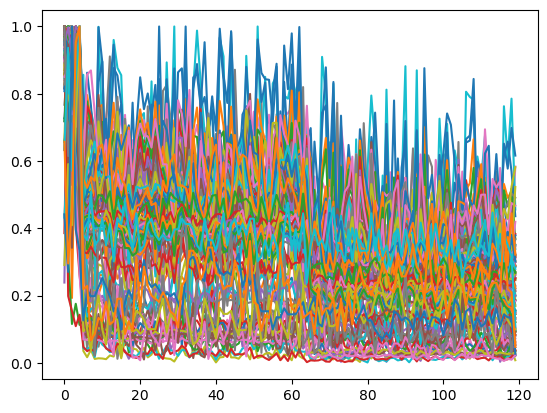

In [9]:
signal_normed = signal/signal.max(axis=-1,keepdims=True)

import matplotlib.pyplot as plt

idx = np.argsort(bvals)
plt.plot(signal_normed[:,idx].T)

In [39]:
# Copy pasted to avoid loading the full data
signal = np.array([4435,  706,  760,  534,  677,  756,  309,  127,  220,  200,   81,
        521,  517,  472,  517,  355,  242,  157,  141,  193,  541,  375,
        305,  631,  281,   95,  179,  385,  143,  679,  529,  664,  680,
        670,  455,  521,  640,  304,  528, 5438,  450,  515,  577,  643,
        518,  617,  694,  619,  551,  494,  672,  626,  577,  499,  633,
        573,  639,  475,  654,  624, 4357,  757,  704,  571,  483,  678,
        525,  459,  444,  538,  778,  534,  612,  385,  558,  579,  336,
        209,  373,  302, 5253,  337,  266,  267,  405,  240,  370,  217,
        317,  228,  344,  341,  381,  269,  325,  360,  231, 3894,  190,
        375,  304,  252,  192,  308,  330,  257,  280,  303,  248,  367,
        222,  234,  161,  296,  372,  233,  318,  247,  157,  117],
      dtype=np.int16)

In [12]:
T1 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/T1map_.nii.gz').get_fdata()
T2 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/T2map_.nii.gz').get_fdata()
B1 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/B1map_.nii.gz').get_fdata()
brain_mask = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/nodif_brain_mask.nii.gz').get_fdata()

In [22]:
T2_in_brain = T2[brain_mask.astype(bool)]
T1_in_brain = T1[brain_mask.astype(bool)]

# Exclude outliers
T2_in_brain = T2_in_brain[T2_in_brain < np.quantile(T2_in_brain, 0.99)]
T1_in_brain = T1_in_brain[T1_in_brain < np.quantile(T1_in_brain, 0.99)]

/tmp/ipykernel_8393/3332188619.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


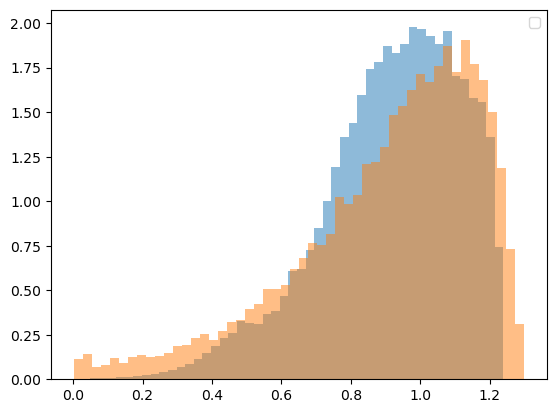

In [110]:
B1_in_brain = B1[brain_mask.astype(bool)]
B1_in_brain = B1_in_brain[B1_in_brain < np.quantile(B1_in_brain, 0.99)]


# Approx B1 distribution
samples = -jax.random.gamma(jax.random.key(0), 2, (10000,))*0.2 + 1.3
plt.hist(B1_in_brain, density=True, bins=50, alpha=0.5)
plt.hist(jax.numpy.abs(samples), density=True, bins=50, alpha=0.5)
plt.legend()
plt.show()

In [72]:
import jax
samples_test = jax.random.gamma(jax.random.key(0), 20, (10000,))*50# + 334

In [66]:
# MLE for gamma distribution


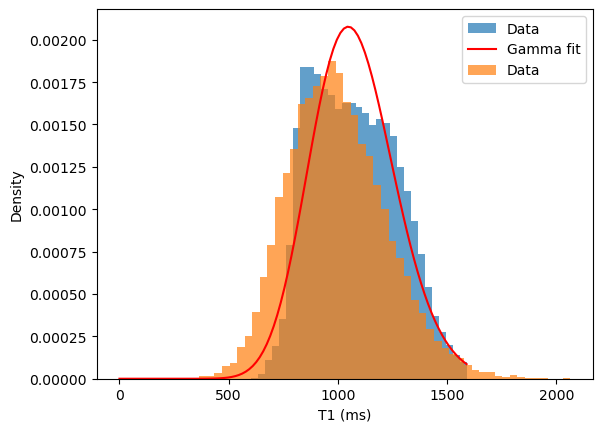

In [73]:
import scipy
# Fit gamma distribution parameters
params = scipy.stats.gamma.fit(T1_in_brain)

# Create histogram of data
plt.hist(T1_in_brain, bins=50, density=True, alpha=0.7, label='Data')

# Plot fitted gamma distribution
x = np.linspace(T1_in_brain.min(), T1_in_brain.max(), 100)
plt.plot(x, scipy.stats.gamma.pdf(x, *params), 'r-', label='Gamma fit')
plt.hist(samples_test, bins=50, density=True, alpha=0.7, label='Data')

plt.xlabel('T1 (ms)')
plt.ylabel('Density')
plt.legend()
plt.show()


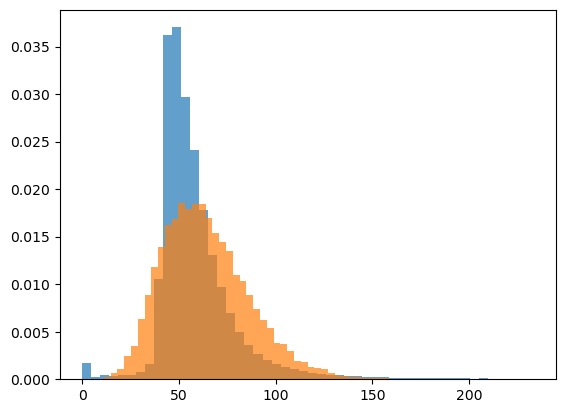

In [85]:

# Create histogram of data
_ = plt.hist(T2_in_brain, bins=50, density=True, alpha=0.7, label='Data')
samples_approx = jax.random.gamma(jax.random.key(0), 8, (10000,))*8# + 334
_ = plt.hist(samples_approx, bins=50, density=True, alpha=0.7, label='Data')

In [28]:
?scipy.stats.gamma.fit

Signature: scipy.stats.gamma.fit(data, *args, **kwds)
Docstring:
Return estimates of shape (if applicable), location, and scale
parameters from data. The default estimation method is Maximum
Likelihood Estimation (MLE), but Method of Moments (MM)
is also available.

Starting estimates for the fit are given by input arguments;
for any arguments not provided with starting estimates,
``self._fitstart(data)`` is called to generate such.

One can hold some parameters fixed to specific values by passing in
keyword arguments ``f0``, ``f1``, ..., ``fn`` (for shape parameters)
and ``floc`` and ``fscale`` (for location and scale parameters,
respectively).

Parameters
----------
data : array_like or `CensoredData` instance
    Data to use in estimating the distribution parameters.
arg1, arg2, arg3,... : floats, optional
    Starting value(s) for any shape-characterizing arguments (those not
    provided will be determined by a call to ``_fitstart(data)``).
    No default value.
**kwds : floats, o

In [56]:

import numpy as np
TRs = 0.0210  # Seems to be in seconds
flipangles = 14 # Seems to be in degree
diffGradAmps = np.array([
    0.74, 3.47, 3.47, 3.47, 3.47, 3.47, 5.20, 5.20, 5.20, 5.20, 5.20,
    3.47, 3.47, 3.47, 3.47, 3.47, 5.20, 5.20, 5.20, 5.20, 3.47, 3.47,
    3.47, 3.47, 3.47, 5.20, 5.20, 5.20, 5.20, 3.47, 3.47, 3.47, 3.47,
    3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 0.74, 3.47, 3.47, 3.47, 3.47,
    3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47,
    3.47, 3.47, 3.47, 3.47, 3.47, 0.74, 3.47, 3.47, 3.47, 3.47, 3.47,
    3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 3.47, 5.20,
    5.20, 5.20, 5.20, 0.74, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20,
    5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 0.74, 5.20,
    5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20,
    5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20, 5.20
])  # Not sure what unit this is
diffGradDur = 0.01016   # Seems also to be in seconds
# Load the NIfTI file
# T1 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/T1map_.nii.gz').get_fdata()[150,150,10]
# T2 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/T2map_.nii.gz').get_fdata()[150,150,10]
# B1 = nib.load('/mnt/c/users/manug/Downloads/Full_brain/Full_brain/B1map_.nii.gz').get_fdata()[150,150,10]
T1 = 1144.0   # Seems to be in ms
T2 = 64.318115234375   # Seems to be in ms
B1 = 0.8348830938339233   # Should be unitless
bvals = np.array([
    0, 3200, 3200, 3200, 3200, 3200, 5700, 5700, 5700, 5700, 5700,
    3200, 3200, 3200, 3200, 3200, 5700, 5700, 5700, 5700, 3200, 3200,
    3200, 3200, 3200, 5700, 5700, 5700, 5700, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 0, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 0, 3200, 3200, 3200, 3200, 3200,
    3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 3200, 5700,
    5700, 5700, 5700, 0, 5700, 5700, 5700, 5700, 5700, 5700, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 0, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700,
    5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700, 5700
])


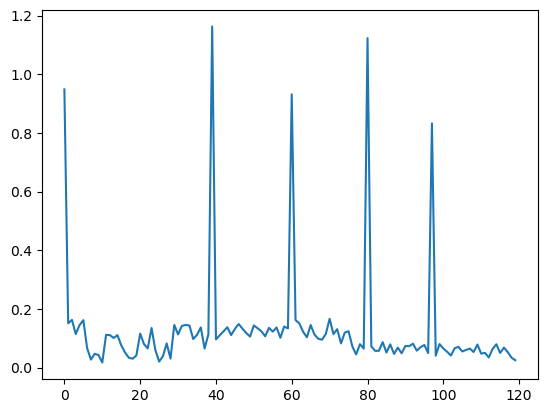

In [57]:
import matplotlib.pyplot as plt
b0 = bvals == 0
s0 = signal[...,b0].mean(-1, keepdims=True)
signal_norm = signal/s0


(0.0, 1.0)

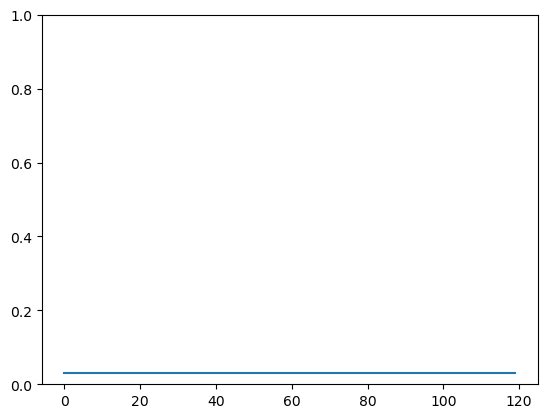

In [78]:
# With raw data
D = 0.08*1e-5
ball3sticks = ball_and_sticks_SSFP(TRs=TRs, flipAngles=flipangles, diffGradAmps=diffGradAmps, diffGradDur=diffGradDur)
signal_pred = ball3sticks(np.array([D]), T1,T2, B1)
plt.plot(signal_pred)
plt.ylim(0,1)

(0.0, 1.0)

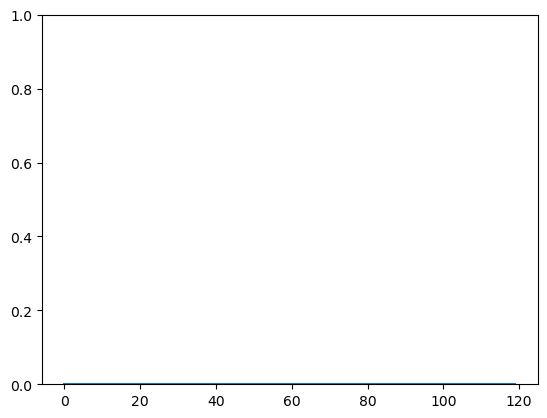

In [83]:
# Convert T1,t2 to seconds such that all are in SI units makes it even worse.
D = 0.08*1e-3
ball3sticks = ball_and_sticks_SSFP(TRs=TRs, flipAngles=flipangles, diffGradAmps=diffGradAmps, diffGradDur=diffGradDur)
signal_pred = ball3sticks(np.array([D]), T1/1000,T2/1000, B1)
plt.plot(signal_pred)
plt.ylim(0,1)

## Effective bvals

The effective b-values seems still seem to be somewhat aligned with the b-values in the data.
But of by a scale of 1e8??? (and not totally recoverable, might be due to the choice of D).

Also T1,T2 and B1 will change per-voxel but bvals are not??? 

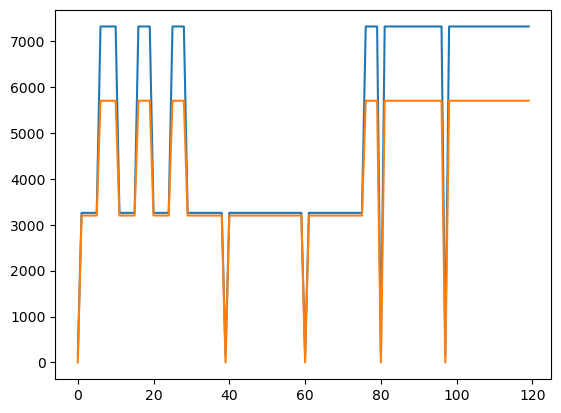

In [90]:
scale_up = 0.9e8

_ = plt.plot(scale_up*-1/D*np.log(ball3sticks(np.array([D]), T1,T2, B1)/ball3sticks(np.array([0.]), T1,T2, B1)))
_ = plt.plot(bvals)